## Sampling

In [ ]:
import numpy as np
import pandas as pd

from itertools import combinations

In [ ]:

RANDOM_STATE = 43

rng = np.random.default_rng(RANDOM_STATE)

df_sampling = pd.DataFrame(
    {
        "user_id": np.arange(1, 101),
        "category": rng.choice(["A", "B", "C"], size=100, p=[0.5, 0.3, 0.2]),
        "score": rng.normal(loc=75, scale=10, size=100).round(2),
    }
)

In [10]:
df_sampling['score'].describe()[['count','mean','std','min','max']]

count    100.000000
mean      74.450700
std       10.637178
min       51.150000
max      104.400000
Name: score, dtype: float64

In [14]:
# [0.5, 0.3, 0.2]
df_sampling['category'].value_counts(normalize=True)

category
A    0.48
B    0.31
C    0.21
Name: proportion, dtype: float64

### Random Sampling

In [19]:
random_sample = df_sampling.sample(n=20, random_state=RANDOM_STATE)


random_sample['score'].describe()[['count','mean','std','min','max']]


count    20.000000
mean     73.371000
std      10.717954
min      51.420000
max      87.780000
Name: score, dtype: float64

In [21]:
random_sample['category'].value_counts(normalize=True)

category
A    0.60
B    0.25
C    0.15
Name: proportion, dtype: float64

In [22]:
df_sampling['category'].value_counts(normalize=True)

category
A    0.48
B    0.31
C    0.21
Name: proportion, dtype: float64

In [20]:
df_sampling['score'].describe()[['count','mean','std','min','max']]

count    100.000000
mean      74.450700
std       10.637178
min       51.150000
max      104.400000
Name: score, dtype: float64

### Stratified Sampling

In [25]:
stratified_sample = (df_sampling
                     .groupby('category',group_keys=False)
                     .sample(frac = 0.2, random_state=RANDOM_STATE)
                     )


In [26]:
stratified_sample['score'].describe()[['count','mean','std','min','max']] 

count    20.000000
mean     74.100500
std      11.479304
min      51.420000
max      93.010000
Name: score, dtype: float64

In [28]:
stratified_sample['category'].value_counts(normalize=True)

category
A    0.5
B    0.3
C    0.2
Name: proportion, dtype: float64

In [29]:
stratified_sample['category'].value_counts()

category
A    10
B     6
C     4
Name: count, dtype: int64

In [30]:
df_sampling['category'].value_counts()

category
A    48
B    31
C    21
Name: count, dtype: int64

In [ ]:
min_size 

In [40]:
stratified_sample = (df_sampling
                     .groupby('category',group_keys=False)
                     .sample(frac = 0.5, random_state=RANDOM_STATE)
                     )

In [42]:
stratified_sample['category'].value_counts(normalize=True)

category
A    0.48
B    0.32
C    0.20
Name: proportion, dtype: float64

In [44]:
df_sampling.head()

df_random_split = df_sampling.assign(
    group = rng.choice(['control','treatment'], size = len(df_sampling)))

df_random_split['group'].value_counts()

group
control      58
treatment    42
Name: count, dtype: int64

In [48]:
df_random_split[['group', 'category']].value_counts()

group      category
control    A           29
treatment  A           19
control    B           18
treatment  B           13
control    C           11
treatment  C           10
Name: count, dtype: int64

In [56]:
df_stratified_split  = (
    df_sampling
    .assign(group = lambda x:  (
        x.groupby('category')['user_id']
        .transform(
            lambda s: rng.permutation(
                ['control'] * (len(s)//2) + ['treatment'] * (len(s) - len(s)//2)
            )
        )
    ))
)

In [55]:
df_stratified_split[['category', 'group']].value_counts()

category  group    
A         control      24
          treatment    24
B         treatment    16
          control      15
C         treatment    11
          control      10
Name: count, dtype: int64

## A/B testing

In [57]:
import numpy as np
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [60]:
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8,
                            alpha = 0.05)

N

99.08032514676708

$$d = \frac{\mu_c-\mu_t}{\sigma}$$

$$n= \left( \frac{Z_{1-\alpha/2}+Z_{1-\beta/2}}{Effect \text{ }Size} \right)^2$$

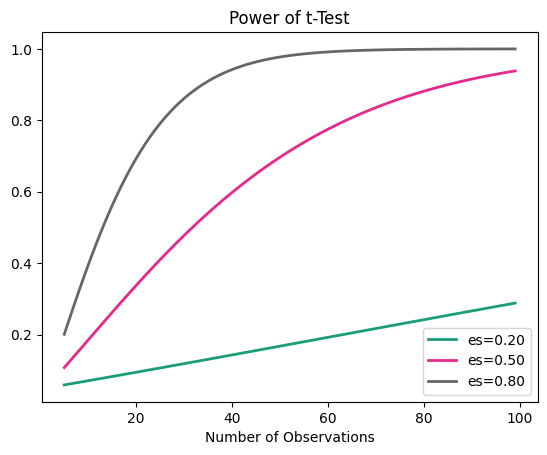

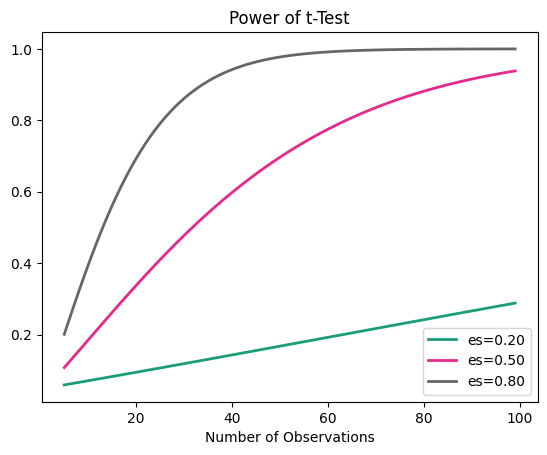

In [ ]:
TTestIndPower().plot_power(dep_var='nobs',  # number of observation
                            nobs=np.array(range(5, 100)), 
                            effect_size=np.array([0.2, 0.5, 0.8]),
                            title='Power of t-Test')

### Step 1

Getting the sample size checkout [here](https://hovhannisyan91.github.io/aca/materials/python/session10.html#hypothesis-testing)


$$n= \left( \frac{Z_{1-\alpha/2}+Z_{1-\beta/2}}{Effect \text{ }Size} \right)^2$$

- $$\mu_c \neq \mu_t$$
- $$\mu_c >= \mu_t$$
- $$\mu_c <= \mu_t$$


In [ ]:
TTestIndPower().solve_power(effect_size = 0.365, power = 0.8,
                            alpha = 0.05, alternative = 'larger')

# մինիմում ամեն մի խմբի համար մեզ պետք է 94 




93.49756951369953

In [68]:
expr = pd.read_csv('../data/ab_testing/experiment.csv')
expr.head()

,user_id,viewing_time,Group
0,4b5630ee914e848e8d07221556b0a2fb,38.354937,control
1,c01f179e4b57ab8bd9de309e6d576c48,49.534278,control
2,11946e7a3ed5e1776e81c0f0ecd383d0,35.468325,control
3,234a2a5581872457b9fe1187d1616b13,69.014875,control
4,dd4ad37ee474732a009111e3456e7ed7,51.547207,control


In [69]:
expr['Group'].value_counts()

Group
control      50
treatment    50
Name: count, dtype: int64

In [71]:
expr.groupby('Group')['viewing_time'].mean()

Group
control      48.386186
treatment    52.081302
Name: viewing_time, dtype: float64

In [82]:
ctrl = expr[expr['Group']=='control']['viewing_time']
treatment = expr[expr['Group']=='treatment']['viewing_time']

In [83]:
ttest = ttest_ind(treatment,ctrl)

In [87]:
ttest

TtestResult(statistic=np.float64(1.6001630656502437), pvalue=np.float64(0.11278139857351255), df=np.float64(98.0))

In [84]:
t_stat, p_value = ttest

In [85]:
f"t-statistics: {t_stat:.4f}"

't-statistics: 1.6002'

In [86]:
f"p-palue: {p_value:.4f}"

'p-palue: 0.1128'

$$\frac{x_i  - x_c}{\text{pooled SD}}$$

In [88]:
diff=treatment.mean() - ctrl.mean()
sd_pooled=math.sqrt((treatment.std()**2+ ctrl.std()**2)/2)

diff/sd_pooled

np.float64(0.32003261313004877)